In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import norm

In [50]:
data = pd.read_json('s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json')

In [56]:
data.head()

,id,data
0,10,"{'appid': 10, 'name': 'Counter-Strike', 'short..."
1,1000000,"{'appid': 1000000, 'name': 'ASCENXION', 'short..."
2,1000010,"{'appid': 1000010, 'name': 'Crown Trick', 'sho..."
3,1000030,"{'appid': 1000030, 'name': 'Cook, Serve, Delic..."
4,1000040,"{'appid': 1000040, 'name': '细胞战争', 'short_desc..."


In [74]:
data.shape

(55691, 2)

In [57]:
expanded = pd.json_normalize(data["data"])
final_df = pd.concat([data["id"], expanded], axis=1)

In [70]:
final_df.to_json("C:/Users/mickt/Documents/final project_files/steam_game_output.json", orient='records')

In [3]:
df = pd.read_json("C:/Users/mickt/Documents/final project_files/steam_game_output.json")

In [4]:
df.head()

,id,appid,name,short_description,developer,publisher,genre,type,categories,owners,...,tags.Coding,tags.Steam Machine,tags.Masterpiece,tags.Rugby,tags.Snooker,tags.Jump Scare,tags.Tile-Matching,tags.Volleyball,tags.Job Simulator,tags.Shop Keeper
0,10,10,Counter-Strike,Play the world's number 1 online action game. ...,Valve,Valve,Action,game,"[Multi-player, Valve Anti-Cheat enabled, Onlin...","10,000,000 .. 20,000,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000000,1000000,ASCENXION,ASCENXION is a 2D shoot 'em up game where you ...,IndigoBlue Game Studio,PsychoFlux Entertainment,"Action, Adventure, Indie",game,"[Single-player, Partial Controller Support, St...","0 .. 20,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000010,1000010,Crown Trick,"Enter a labyrinth that moves as you move, wher...",NEXT Studios,"Team17, NEXT Studios","Adventure, Indie, RPG, Strategy",game,"[Single-player, Partial Controller Support, St...","200,000 .. 500,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000030,1000030,"Cook, Serve, Delicious! 3?!","Cook, serve and manage your food truck as you ...",Vertigo Gaming Inc.,Vertigo Gaming Inc.,"Action, Indie, Simulation, Strategy",game,"[Multi-player, Single-player, Co-op, Steam Ach...","100,000 .. 200,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000040,1000040,细胞战争,这是一款打击感十足的细胞主题游戏！操作简单但活下去却不简单，“你”作为侵入人体的细菌病毒，通...,DoubleC Games,DoubleC Games,"Action, Casual, Indie, Simulation",game,[Single-player],"0 .. 20,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(55691, 465)

In [4]:
df = df.dropna(axis=1, thresh=int(len(df) * 0.02))

In [4]:
df.shape

(55691, 168)

In [27]:
non_numeric = df.select_dtypes(exclude=["number", "bool"]).columns
print(non_numeric.tolist())

['name', 'short_description', 'developer', 'publisher', 'genre', 'type', 'categories', 'owners', 'languages', 'release_date', 'required_age', 'website', 'header_image']


In [28]:
numeric = df.select_dtypes(include=["number", "bool"]).columns
print(numeric.tolist())

['id', 'appid', 'positive', 'negative', 'price', 'initialprice', 'discount', 'ccu', 'tags.Action', 'tags.FPS', 'tags.Multiplayer', 'tags.Shooter', 'tags.Classic', 'tags.First-Person', 'tags.Tactical', "tags.1990's", 'tags.PvP', 'tags.Old School', 'tags.Military', 'tags.Strategy', 'tags.Survival', 'tags.Score Attack', 'platforms.windows', 'platforms.mac', 'platforms.linux', "tags.Shoot 'Em Up", 'tags.Bullet Hell', 'tags.Side Scroller', 'tags.Difficult', 'tags.2D', 'tags.Controller', 'tags.Minimalist', 'tags.Colorful', 'tags.Abstract', 'tags.Atmospheric', 'tags.Adventure', 'tags.Singleplayer', 'tags.Indie', 'tags.Great Soundtrack', 'tags.Rogue-like', 'tags.Turn-Based Combat', 'tags.RPG', 'tags.Rogue-lite', 'tags.Dungeon Crawler', 'tags.Turn-Based', 'tags.Female Protagonist', 'tags.Turn-Based Strategy', 'tags.Replay Value', 'tags.Action-Adventure', 'tags.Fantasy', 'tags.Top-Down', 'tags.Magic', 'tags.Management', 'tags.Casual', 'tags.Arcade', 'tags.Funny', 'tags.Simulation', 'tags.Comedy'

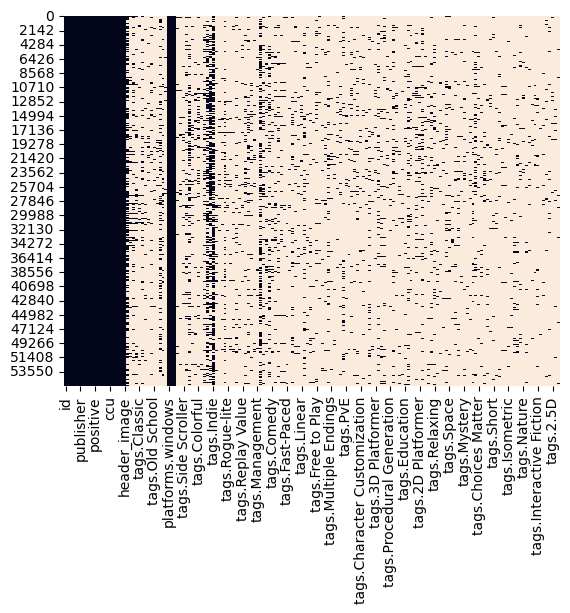

In [33]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [44]:
print( df["tags.2.5D"].isnull().sum(), df["publisher"].isnull().sum())

54572 0


# General Analysis of data distribution

## Which publisher has released the most games on Steam?

In [182]:
df['publisher']

0                                                 Valve
1                              PsychoFlux Entertainment
2                                  Team17, NEXT Studios
3                                   Vertigo Gaming Inc.
4                                         DoubleC Games
                              ...                      
55686    Caltech/IPAC, NASA's Jet Propulsion Laboratory
55687                                    FlairBot Games
55688                            RADiCAL Solutions, LLC
55689                                            张八万工作室
55690                          PsychoFlux Entertainment
Name: publisher, Length: 55691, dtype: object

publisher
Big Fish Games     422
8floor             202
SEGA               165
Strategy First     151
Square Enix        141
Choice of Games    140
Sekai Project      132
HH-Games           132
                   132
Ubisoft            127
Name: count, dtype: int64


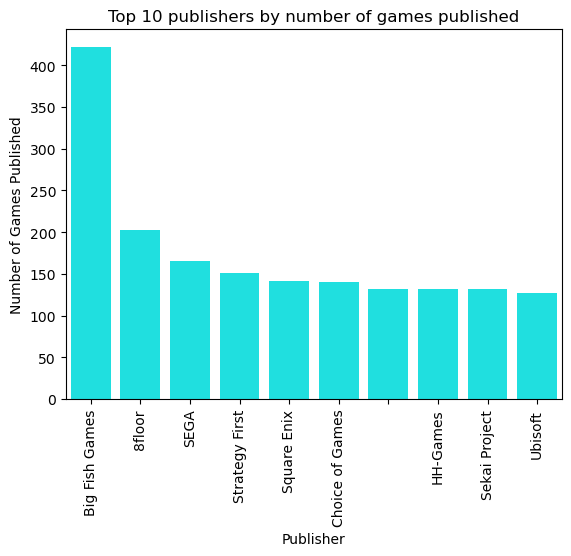

In [75]:
print(df['publisher'].value_counts().sort_values(ascending=False).head(10))
sns.barplot(x=df['publisher'].value_counts().head(10).index, y=df['publisher'].value_counts().head(10).values, color="cyan")
plt.xticks(rotation=90)
plt.xlabel('Publisher')
plt.ylabel('Number of Games Published')
plt.title('Top 10 publishers by number of games published')
plt.show()

## What are the best rated games?


In [184]:
df['name']

0                        Counter-Strike
1                             ASCENXION
2                           Crown Trick
3           Cook, Serve, Delicious! 3?!
4                                  细胞战争
                      ...              
55686       NASA's Exoplanet Excursions
55687                            Bruken
55688                 Studio by RADiCAL
55689    Fantasy Sino-Japanese War 幻想甲午
55690                     Bouncing Hero
Name: name, Length: 55691, dtype: object

c:\Users\mickt\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) DejaVu Sans.

c:\Users\mickt\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 32990 (\N{CJK UNIFIED IDEOGRAPH-80DE}) missing from font(s) DejaVu Sans.

c:\Users\mickt\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 25112 (\N{CJK UNIFIED IDEOGRAPH-6218}) missing from font(s) DejaVu Sans.

c:\Users\mickt\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 20105 (\N{CJK UNIFIED IDEOGRAPH-4E89}) missing from font(s) DejaVu Sans.

c:\Users\mickt\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 24178 (\N{CJK UNIFIED IDEOGRAPH-5E72}) missing from font(s) DejaVu Sans.

c:\Users\mickt\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 25903 (\N{CJK UNIFIED IDEOGRAPH-652F}) missing from fo

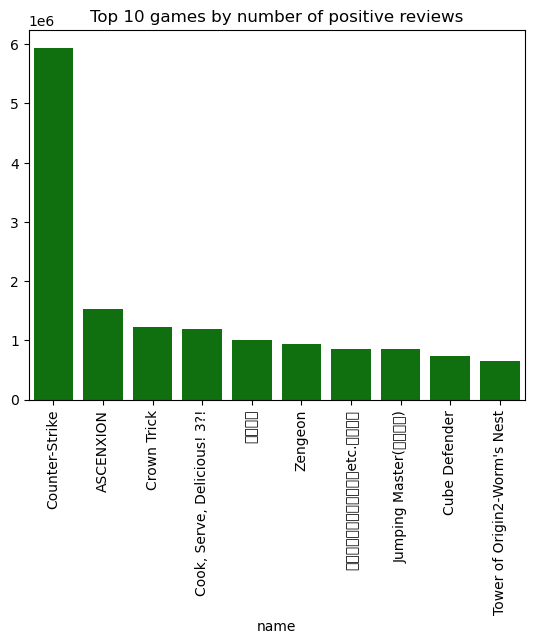

In [185]:
sns.barplot(x=df['name'].head(10), y=df['positive'].sort_values(ascending=False).head(10).values, color="green")
plt.xticks(rotation=90)
plt.title('Top 10 games by number of positive reviews')
plt.show()

## Are there years with more releases? Were there more or fewer game releases during the Covid, for example?

In [186]:
df['release_date']

0       2000-11-01
1       2021-05-14
2       2020-10-16
3       2020-10-14
4       2019-03-30
           ...    
55686   2019-04-18
55687   2019-04-11
55688   2019-01-04
55689   2019-01-11
55690   2019-09-01
Name: release_date, Length: 55691, dtype: datetime64[ns]

In [187]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

In [188]:
df["release_year"] = df["release_date"].dt.year

release_year
2021.0    8805
2020.0    8287
2018.0    7663
2022.0    7451
2019.0    6949
2017.0    6006
2016.0    4176
2015.0    2566
2014.0    1550
2013.0     469
Name: count, dtype: int64


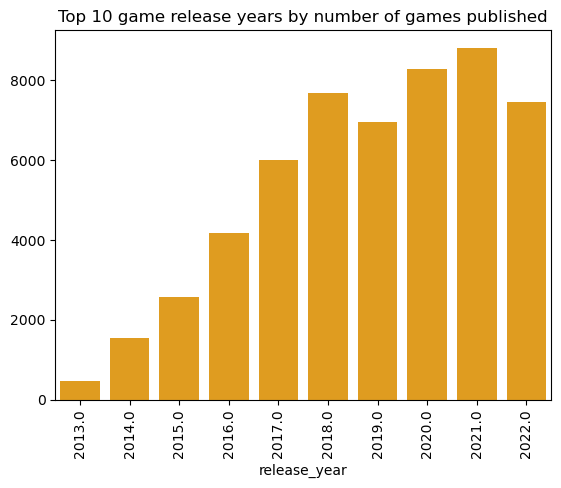

In [189]:
print(df['release_year'].value_counts().sort_values(ascending=False).head(10))
sns.barplot(x=df['release_year'].sort_values(ascending=False).value_counts().head(10).index, y=df['release_year'].value_counts().head(10).values, color="orange")
plt.xticks(rotation=90)
plt.title('Top 10 game release years by number of games published')
plt.show()

In [190]:
year_counts = (
    df["release_year"]
    .value_counts()
    .head(10)
    .reset_index()
)

year_counts.columns = ["Year", "Games"]

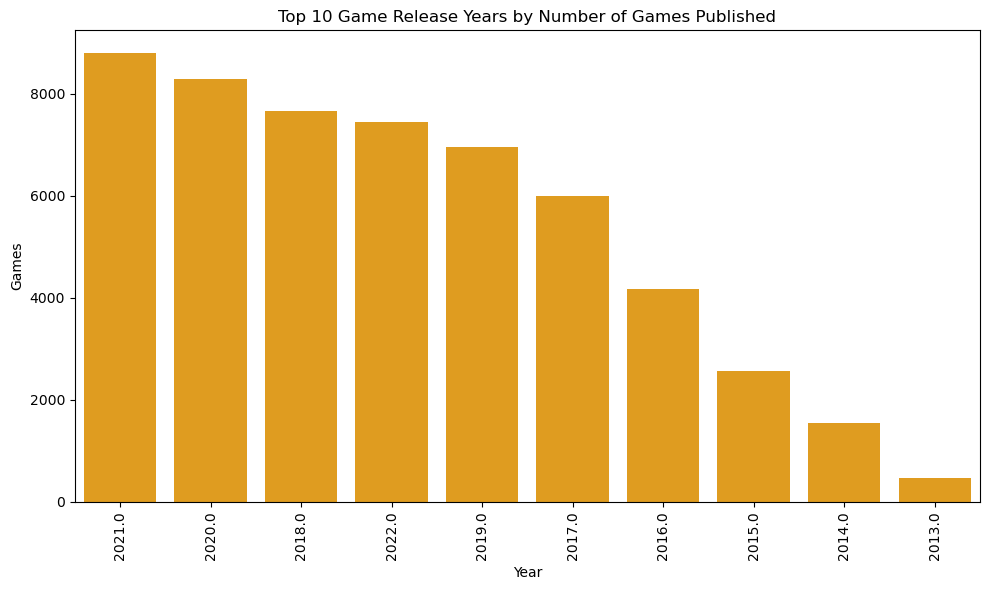

In [191]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=year_counts,
    x="Year",
    y="Games",
    order=year_counts["Year"],
    color="orange" 
)

plt.xticks(rotation=90)
plt.title("Top 10 Game Release Years by Number of Games Published")
plt.tight_layout()
plt.show()


## How are the prizes distributed? Are there many games with a discount?


In [192]:
log_prices = np.log1p(prices)

mu_log, sigma_log = norm.fit(log_prices)
print(f"Fitted parameters: mu = {mu_log}, sigma = {sigma_log}")

Fitted parameters: mu = 6.328916054531076, sigma = 1.01687555945173


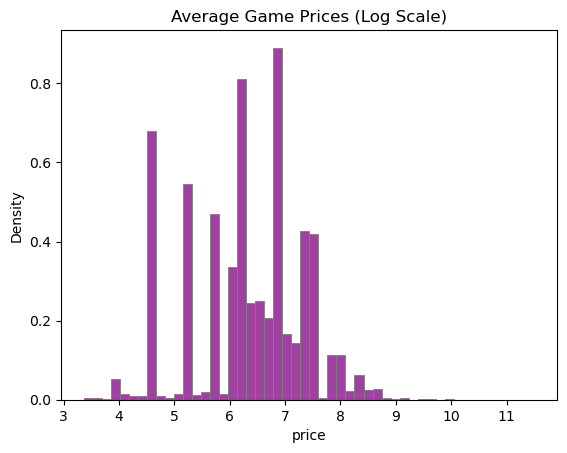

In [193]:
sns.histplot(np.log1p(prices), bins=50, stat="density", color="purple", edgecolor="grey")
plt.title("Average Game Prices (Log Scale)")
plt.show()

In [194]:
df['discount']

0         0
1         0
2        70
3         0
4         0
         ..
55686     0
55687     0
55688     0
55689     0
55690     0
Name: discount, Length: 55691, dtype: int64

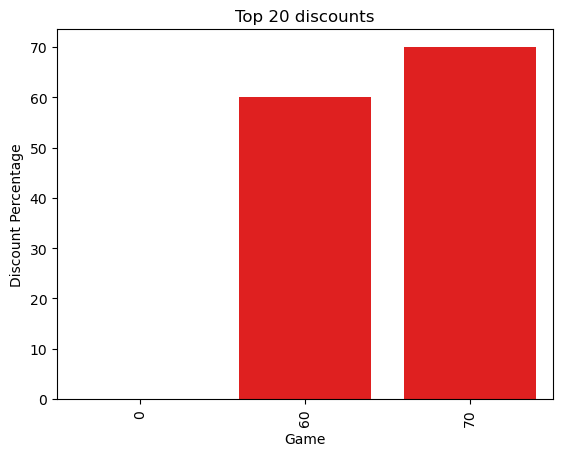

In [74]:
sns.barplot(x = df['discount'].head(20), y=df['discount'].head(20).values, color="red")
plt.xticks(rotation=90)
plt.xlabel('Game')
plt.ylabel('Discount Percentage')
plt.title('Top 20 discounts')
plt.show()

## What are the most represented languages?


languages
English                                              29163
English, Russian                                      1881
English, Simplified Chinese                           1200
English, Japanese                                     1015
English, Not supported, Simplified Chinese             683
English, German                                        605
English, French                                        510
English, French, Italian, German, Spanish - Spain      493
English, Portuguese - Brazil                           463
English, Simplified Chinese, Traditional Chinese       326
Name: count, dtype: int64


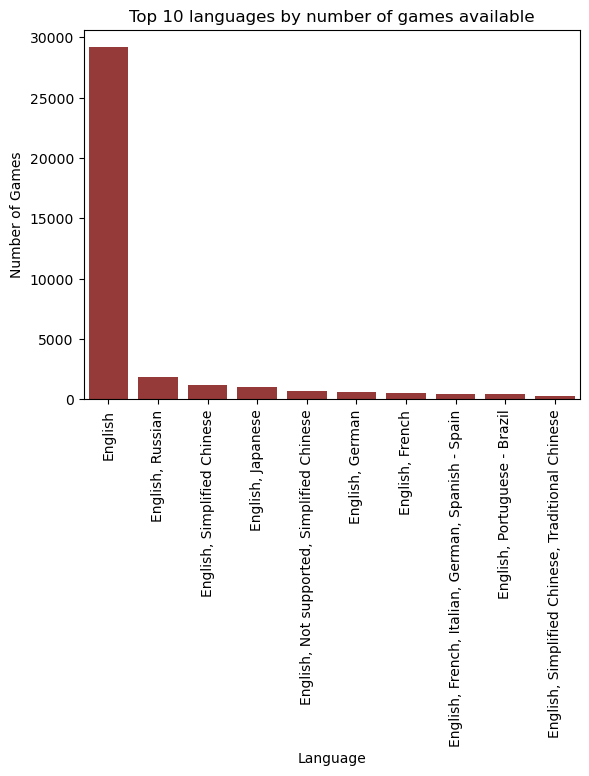

In [73]:
print(df['languages'].value_counts().sort_values(ascending=False).head(10))
sns.barplot(x=df['languages'].value_counts().head(10).index, y=df['languages'].value_counts().head(10).values, color="brown")
plt.xticks(rotation=90)
plt.xlabel('Language')
plt.ylabel('Number of Games')
plt.title('Top 10 languages by number of games available')
plt.show()

## Are there many games prohibited for children under 16/18?

In [197]:
df["required_age"]

0        0
1        0
2        0
3        0
4        0
        ..
55686    0
55687    0
55688    0
55689    0
55690    0
Name: required_age, Length: 55691, dtype: object

required_age
0     55030
15      264
18      223
16       38
17       38
12       32
13       26
14       10
10        7
6         4
Name: count, dtype: int64


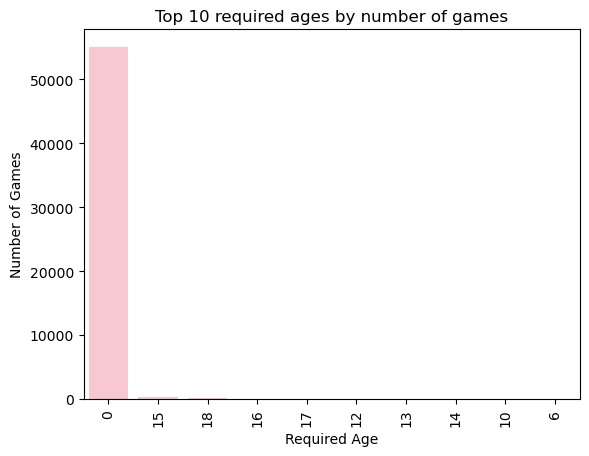

In [72]:
print(df['required_age'].value_counts().sort_values(ascending=False).head(10))
sns.barplot(x=df['required_age'].value_counts().head(10).index, y=df['required_age'].value_counts().head(10).values, color="pink")
plt.xticks(rotation=90)
plt.xlabel('Required Age')
plt.ylabel('Number of Games')
plt.title('Top 10 required ages by number of games')
plt.show()

# Genres analysis

## What are the most represented genres ?


In [203]:
df['genre']

0                                     Action
1                   Action, Adventure, Indie
2            Adventure, Indie, RPG, Strategy
3        Action, Indie, Simulation, Strategy
4          Action, Casual, Indie, Simulation
                        ...                 
55686                              Education
55687               Adventure, Casual, Indie
55688                   Animation & Modeling
55689     Indie, RPG, Strategy, Early Access
55690                  Action, Casual, Indie
Name: genre, Length: 55691, dtype: object

genre
Action, Indie               3460
Casual, Indie               3060
Action, Adventure, Indie    2783
Adventure, Indie            2316
Action, Casual, Indie       1914
Adventure, Casual, Indie    1811
Indie                       1756
Action                      1633
Casual                      1433
Adventure                   1021
Name: count, dtype: int64


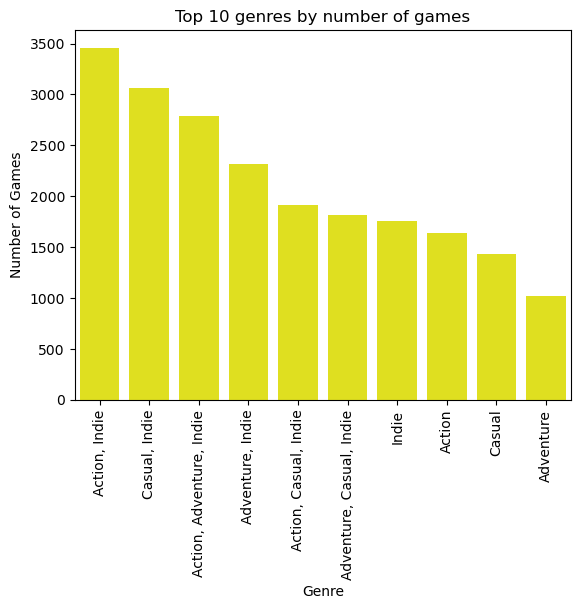

In [71]:
print(df['genre'].value_counts().sort_values(ascending=False).head(10))
sns.barplot(x=df['genre'].value_counts().head(10).index, y=df['genre'].value_counts().head(10).values, color="yellow")
plt.xticks(rotation=90)
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.title('Top 10 genres by number of games')
plt.show()

## Are there any genres that have a better positive/negative review ratio?


In [205]:
df['genre']

0                                     Action
1                   Action, Adventure, Indie
2            Adventure, Indie, RPG, Strategy
3        Action, Indie, Simulation, Strategy
4          Action, Casual, Indie, Simulation
                        ...                 
55686                              Education
55687               Adventure, Casual, Indie
55688                   Animation & Modeling
55689     Indie, RPG, Strategy, Early Access
55690                  Action, Casual, Indie
Name: genre, Length: 55691, dtype: object

In [214]:
df['genre'].unique()

array(['Action', 'Action, Adventure, Indie',
       'Adventure, Indie, RPG, Strategy', ...,
       'Action, Free to Play, Indie, Massively Multiplayer, Racing, RPG, Simulation',
       'Action, Indie, Massively Multiplayer, RPG, Strategy, Early Access',
       'Adventure, Casual, Free to Play, Massively Multiplayer, Strategy'],
      shape=(1832,), dtype=object)

In [9]:
genre_note = df['positive'] / df['negative']
genre_note1 = df["negative"]
print(genre_note.shape)

(55691,)


In [25]:
df_genre_ratio = df.melt(
    id_vars='genre', 
    value_vars=['positive', 'negative'], 
    var_name='review', 
    value_name='count'
)

In [26]:
df_genre_ratio.head()

,genre,review,count
0,Action,positive,201215
1,"Action, Adventure, Indie",positive,27
2,"Adventure, Indie, RPG, Strategy",positive,4032
3,"Action, Indie, Simulation, Strategy",positive,1575
4,"Action, Casual, Indie, Simulation",positive,0


In [28]:
df_genre_ratio['total'] = df['positive'] + df['negative']
df_genre_ratio['pos_ratio'] = df['positive'] / df_genre_ratio['total']

In [41]:
df_genre_ratio.head()

,genre,review,count,total,pos_ratio
0,Action,positive,201215,206414.0,0.974813
1,"Action, Adventure, Indie",positive,27,32.0,0.843750
2,"Adventure, Indie, RPG, Strategy",positive,4032,4678.0,0.861907
3,"Action, Indie, Simulation, Strategy",positive,1575,1690.0,0.931953
4,"Action, Casual, Indie, Simulation",positive,0,1.0,0.000000


genre
Action, Indie               3460
Casual, Indie               3060
Action, Adventure, Indie    2783
Adventure, Indie            2316
Action, Casual, Indie       1914
Adventure, Casual, Indie    1811
Indie                       1756
Action                      1633
Casual                      1433
Adventure                   1021
Name: count, dtype: int64


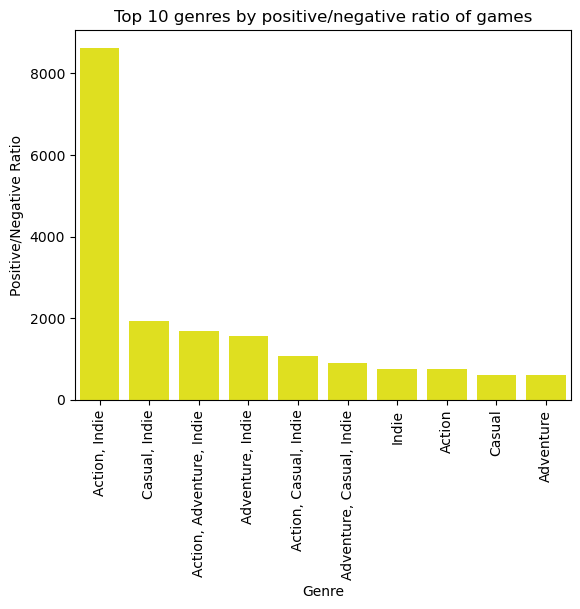

In [70]:
print(df['genre'].value_counts().sort_values(ascending=False).head(10))
sns.barplot(x =df['genre'].value_counts().head(10).index, y=df_genre_ratio['pos_ratio'].value_counts().head(10).values, color="yellow")
plt.xticks(rotation=90)
plt.xlabel('Genre')
plt.ylabel('Positive/Negative Ratio')
plt.title('Top 10 genres by positive/negative ratio of games')
plt.show()



## Do some publishers have favorite genres?


In [34]:
print(df['genre'].shape, df['publisher'].shape)

(55691,) (55691,)


In [35]:
print(df['genre'].value_counts().sort_values(ascending=False).head(10), df['publisher'].value_counts().sort_values(ascending=False).head(10))

genre
Action, Indie               3460
Casual, Indie               3060
Action, Adventure, Indie    2783
Adventure, Indie            2316
Action, Casual, Indie       1914
Adventure, Casual, Indie    1811
Indie                       1756
Action                      1633
Casual                      1433
Adventure                   1021
Name: count, dtype: int64 publisher
Big Fish Games     422
8floor             202
SEGA               165
Strategy First     151
Square Enix        141
Choice of Games    140
Sekai Project      132
HH-Games           132
                   132
Ubisoft            127
Name: count, dtype: int64


In [30]:
df_norm = (
    df[['publisher', 'genre']]
    .dropna()
    .assign(
        publisher=lambda x: x['publisher'].str.split(','),
        genre=lambda x: x['genre'].str.split(',')
    )
    .explode('publisher')
    .explode('genre')
)

df_norm['publisher'] = df_norm['publisher'].str.strip()
df_norm['genre'] = df_norm['genre'].str.strip()



In [31]:
counts = (
    df_norm
    .groupby(['publisher', 'genre'])
    .size()
    .reset_index(name='n_games')
)

In [32]:
counts['total'] = counts.groupby('publisher')['n_games'].transform('sum')
counts['share'] = counts['n_games'] / counts['total']


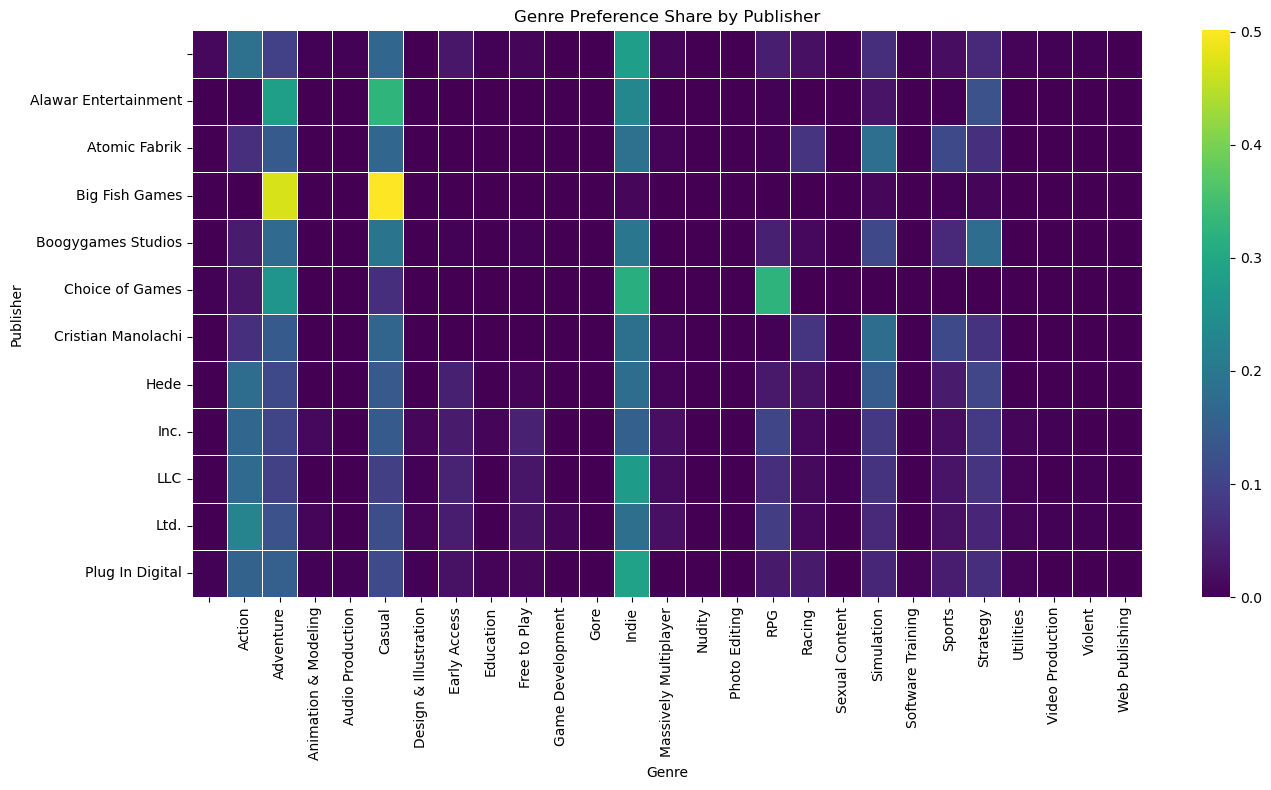

In [33]:
top_pubs = (
    counts.groupby('publisher')['total']
    .max()
    .sort_values(ascending=False)
    .head(12)
    .index
)

heat = counts[counts['publisher'].isin(top_pubs)]

pivot = heat.pivot(
    index='publisher',
    columns='genre',
    values='share'
).fillna(0)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='viridis', linewidths=0.5)

plt.title("Genre Preference Share by Publisher")
plt.xlabel("Genre")
plt.ylabel("Publisher")
plt.tight_layout()
plt.show()


## What are the most lucrative genres?

In [40]:
print(df['owners'].value_counts().sort_values(ascending=False).head(10))

owners
0 .. 20,000                 38072
20,000 .. 50,000             7285
50,000 .. 100,000            3695
100,000 .. 200,000           2519
200,000 .. 500,000           2162
500,000 .. 1,000,000          933
1,000,000 .. 2,000,000        526
2,000,000 .. 5,000,000        335
5,000,000 .. 10,000,000        97
10,000,000 .. 20,000,000       41
Name: count, dtype: int64


In [48]:
def owners_to_midpoint(x):
    low, high = x.replace(',', '').split(' .. ')
    return (int(low) + int(high)) / 2

df['owners_mid'] = df['owners'].dropna().apply(owners_to_midpoint)

In [49]:
df['estimated_revenue'] = df['owners_mid'] * df['price']

In [50]:
df_genre = (
    df[['genre', 'estimated_revenue']]
    .dropna()
    .assign(genre=lambda x: x['genre'].str.split(','))
    .explode('genre')
)

df_genre['genre'] = df_genre['genre'].str.strip()

In [51]:
genre_revenue = (
    df_genre
    .groupby('genre')['estimated_revenue']
    .sum()
    .sort_values(ascending=False)
)

[16.5851555  13.965       8.16849333  7.996375    7.92668864  6.58191667
  5.27836125  4.8978085   4.4985      3.7485    ] billion dollars
genre
Action, Adventure, Massively Multiplayer, RPG                                           1.658516e+10
Casual, Indie, Animation & Modeling, Design & Illustration, Photo Editing, Utilities    1.396500e+10
Action, Adventure, Racing, Sports                                                       8.168493e+09
Action, Adventure, Massively Multiplayer, RPG, Simulation, Strategy                     7.996375e+09
Action, Adventure, Indie, Massively Multiplayer, RPG                                    7.926689e+09
Action, Massively Multiplayer, Racing                                                   6.581917e+09
Action, Adventure, Racing, Simulation, Sports                                           5.278361e+09
Action, Adventure, Massively Multiplayer                                                4.897808e+09
Action, Adventure, Racing, Sports, Strategy    

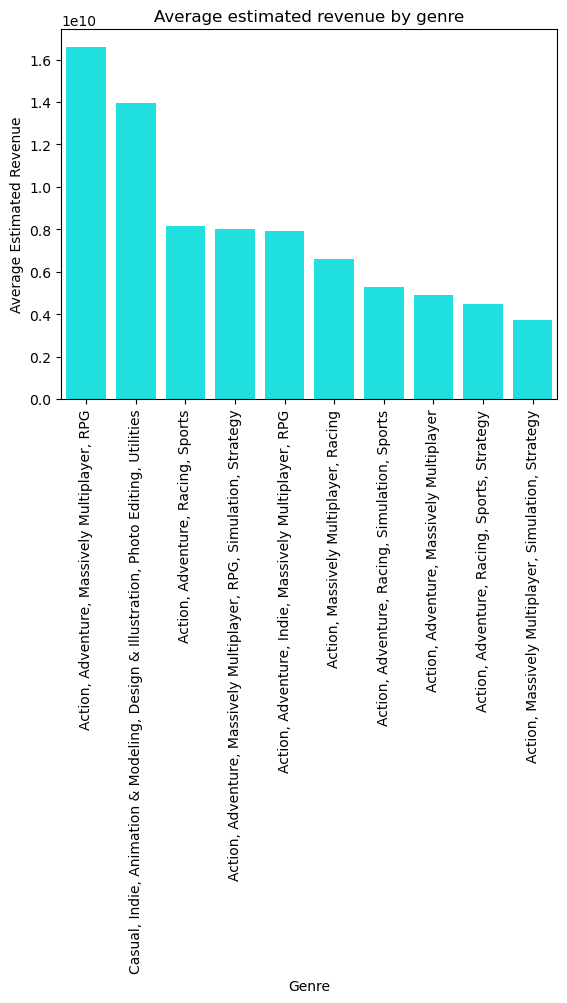

In [69]:
avg_revenue = (
    df
    .groupby('genre')['estimated_revenue']
    .mean()
    .sort_values(ascending=False)
)
print('{} billion dollars'.format(avg_revenue.head(10).values / 1e9))
print(avg_revenue.head(10))

sns.barplot(x=avg_revenue.head(10).index, y=avg_revenue.head(10).values, color="cyan")
plt.xticks(rotation=90)
plt.xlabel('Genre')
plt.ylabel('Average Estimated Revenue')
plt.title('Average estimated revenue by genre')
plt.show()

# Platform analysis

## Are most games available on Windows/Mac/Linux instead?

In [84]:
print(df['platforms.windows'].value_counts(), df['platforms.mac'].value_counts(), df['platforms.linux'].value_counts())

platforms.windows
True     55676
False       15
Name: count, dtype: int64 platforms.mac
False    42921
True     12770
Name: count, dtype: int64 platforms.linux
False    47233
True      8458
Name: count, dtype: int64


In [98]:
platform_counts = {
    'Windows': df['platforms.windows'].eq(True).sum(),
    'Mac': df['platforms.mac'].eq(True).sum(),
    'Linux': df['platforms.linux'].eq(True).sum()
}

platform_df = (
    pd.DataFrame.from_dict(platform_counts, orient='index', columns=['count'])
    .reset_index()
    .rename(columns={'index': 'platform'})
)

  platform  count
0  Windows  55676
1      Mac  12770
2    Linux   8458


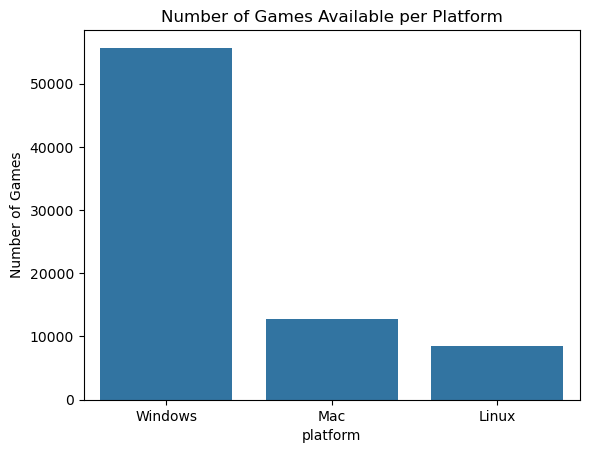

In [100]:
print(platform_df)
sns.barplot(
    data=platform_df,
    x='platform',
    y='count'
)

plt.title("Number of Games Available per Platform")
plt.ylabel("Number of Games")
plt.show()


## Do certain genres tend to be preferentially available on certain platforms?

In [5]:
platform_cols = ['platforms.windows', 'platforms.mac', 'platforms.linux']

df_long = (
    df[['genre'] + platform_cols]
    .dropna(subset=['genre'])
    .assign(genre=lambda x: x['genre'].str.split(','))
    .explode('genre')
)

df_long['genre'] = df_long['genre'].str.strip()



In [6]:
df_long = df_long.melt(
    id_vars='genre',
    value_vars=platform_cols,
    var_name='platform',
    value_name='available'
)

df_long['platform'] = df_long['platform'].str.replace('platforms.', '')


In [7]:
df_long = df_long[df_long['available']]

In [8]:
counts = (
    df_long
    .groupby(['genre', 'platform'])
    .size()
    .reset_index(name='n_games')
)

counts['total_genre'] = counts.groupby('genre')['n_games'].transform('sum')
counts['platform_share'] = counts['n_games'] / counts['total_genre']


In [9]:
top_genres = (
    counts.groupby('genre')['total_genre']
    .max()
    .sort_values(ascending=False)
    .head(12)
    .index
)

heat = counts[counts['genre'].isin(top_genres)]


In [11]:
platform_counts = {
    'Windows': df['platforms.windows'].eq(True).sum(),
    'Mac': df['platforms.mac'].eq(True).sum(),
    'Linux': df['platforms.linux'].eq(True).sum()
}

platform_df = (
    pd.DataFrame.from_dict(platform_counts, orient='index', columns=['count'])
    .reset_index()
    .rename(columns={'index': 'platform'})
)

  platform  count
0  Windows  55676
1      Mac  12770
2    Linux   8458


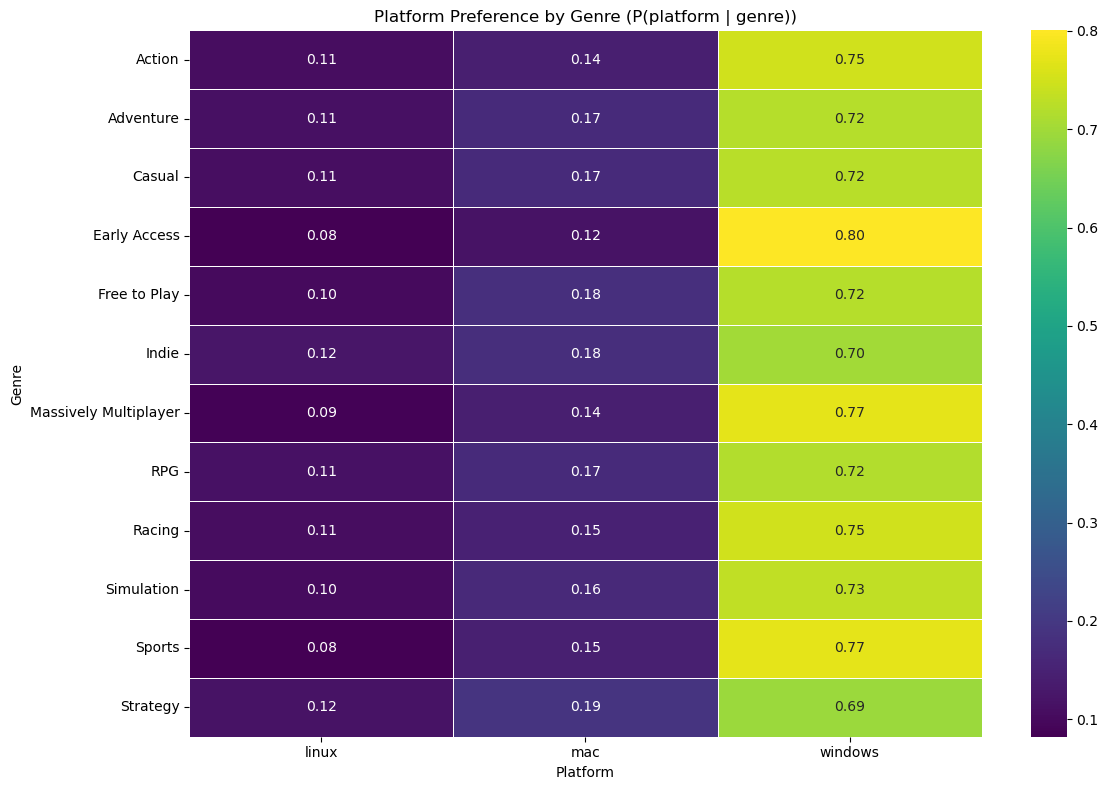

In [12]:
print(platform_df)
pivot = heat.pivot(
    index='genre',
    columns='platform',
    values='platform_share'
)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Platform Preference by Genre (P(platform | genre))")
plt.xlabel("Platform")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()
